# Analiza SHAP modelu sentymentu

Notebook realizuje etap interpretacji modelu klasyfikacji sentymentu. Odtwarzany jest ten sam pipeline co w notebooku `02_model_sentiment_classification.ipynb`: podział 80/20, reprezentacja TF-IDF oraz regresja logistyczna z wagami klas. Następnie dla wytrenowanego modelu obliczane są wartości SHAP i zapisywane wykresy interpretacyjne do katalogu `figures/`.

## Założenie interpretacyjne

Model uczy się przewidywać etykiety sentymentu wygenerowane automatycznie metodą VADER. Interpretacja SHAP pokazuje więc, które słowa i frazy pomagają modelowi odtwarzać etykiety VADER, a nie bezpośrednio ręcznie oceniany sentyment polityczny.

In [2]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

## Konfiguracja

Parametry modelu są zgodne z notebookiem modelującym. Analiza SHAP jest liczona na próbce zbioru testowego, aby zachować rozsądny czas obliczeń przy 5 000 cech TF-IDF.

In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "trump_tweets_preprocessed.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
SHAP_TABLE_PATH = PROJECT_ROOT / "data" / "shap_top_features.csv"
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 5000
BACKGROUND_SIZE = 200
EXPLAIN_SIZE = 1500
TOP_N = 15

DATA_PATH, FIGURES_DIR, SHAP_TABLE_PATH

(PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/data/trump_tweets_preprocessed.csv'),
 PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/figures'),
 PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/data/shap_top_features.csv'))

## Wczytanie danych

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["clean_text", "sentiment"]).copy()

print(f"Liczba rekordów: {len(df):,}".replace(",", " "))
display(df[["clean_text", "sentiment", "vader_score"]].head())

Liczba rekordów: 42 998


,clean_text,sentiment,vader_score
0,be sure to tune in and watch donald trump on l...,positive,0.5255
1,donald trump will be appearing on the view tom...,positive,0.7712
2,donald trump reads top ten financial tips on l...,positive,0.6468
3,new blog post celebrity apprentice finale and ...,neutral,0.0000
4,my persona will never be that of a wallflower ...,neutral,0.0000


## Odtworzenie modelu z etapu 02

In [5]:
X = df["clean_text"].astype(str)
y = df["sentiment"].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
labels = list(model.classes_)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("Klasy:", labels)
print(f"Liczba cech TF-IDF: {X_train.shape[1]:,}".replace(",", " "))

Accuracy: 0.8106
Macro F1: 0.7859
Weighted F1: 0.8160
Klasy: ['negative', 'neutral', 'positive']
Liczba cech TF-IDF: 5 000


## Obliczenie wartości SHAP

Dla regresji logistycznej z cechami TF-IDF używany jest `shap.LinearExplainer`. Tło SHAP pochodzi z losowej próbki zbioru treningowego, a wyjaśniane przykłady z losowej próbki zbioru testowego.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
background_size = min(BACKGROUND_SIZE, X_train.shape[0])
explain_size = min(EXPLAIN_SIZE, X_test.shape[0])

background_idx = rng.choice(X_train.shape[0], size=background_size, replace=False)
explain_idx = rng.choice(X_test.shape[0], size=explain_size, replace=False)

X_background = X_train[background_idx]
X_explain = X_test[explain_idx]
explained_text = X_test_text.iloc[explain_idx].reset_index(drop=True)
explained_labels = y_test.iloc[explain_idx].reset_index(drop=True)

explainer = shap.LinearExplainer(model, X_background)
raw_shap_values = explainer.shap_values(X_explain)

if isinstance(raw_shap_values, list):
    shap_values = np.stack(raw_shap_values, axis=-1)
else:
    shap_values = np.asarray(raw_shap_values)

if shap_values.shape[0] == len(labels) and shap_values.ndim == 3:
    shap_values = np.moveaxis(shap_values, 0, -1)

print("Kształt macierzy SHAP:", shap_values.shape)
print("Przykłady interpretowane przez SHAP:", explain_size)
print("Próbka tła SHAP:", background_size)

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Kształt macierzy SHAP: (1500, 5000, 3)
Przykłady interpretowane przez SHAP: 1500
Próbka tła SHAP: 200


## Najważniejsze cechy według SHAP

Dla każdej klasy liczona jest średnia wartość bezwzględna SHAP dla wszystkich analizowanych tweetów. Im wyższa wartość, tym silniej dana cecha wpływała na wynik modelu dla tej klasy.

In [7]:
feature_names = np.array(vectorizer.get_feature_names_out())
rows = []

for class_index, class_name in enumerate(labels):
    class_shap = shap_values[:, :, class_index]
    mean_abs_shap = np.abs(class_shap).mean(axis=0)
    mean_signed_shap = class_shap.mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-TOP_N:][::-1]

    for rank, feature_index in enumerate(top_indices, start=1):
        rows.append({
            "class": class_name,
            "rank": rank,
            "feature": feature_names[feature_index],
            "mean_abs_shap": mean_abs_shap[feature_index],
            "mean_signed_shap": mean_signed_shap[feature_index],
        })

shap_importance_df = pd.DataFrame(rows)
shap_importance_df.to_csv(SHAP_TABLE_PATH, index=False)
shap_importance_df

,class,rank,feature,mean_abs_shap,mean_signed_shap
0,negative,1,great,0.175641,0.004299
1,negative,2,thanks,0.069686,-0.013738
2,negative,3,trump,0.063040,-0.001492
3,negative,4,realdonaldtrump,0.057644,0.002052
4,negative,5,bad,0.055096,0.013316
5,negative,6,com,0.048032,-0.002243
6,negative,7,twitter com,0.033994,-0.002835
7,negative,8,best,0.030608,0.002125
8,negative,9,fake,0.029821,0.008407
9,negative,10,attack,0.026031,-0.009689


## Wykresy SHAP dla klas sentymentu

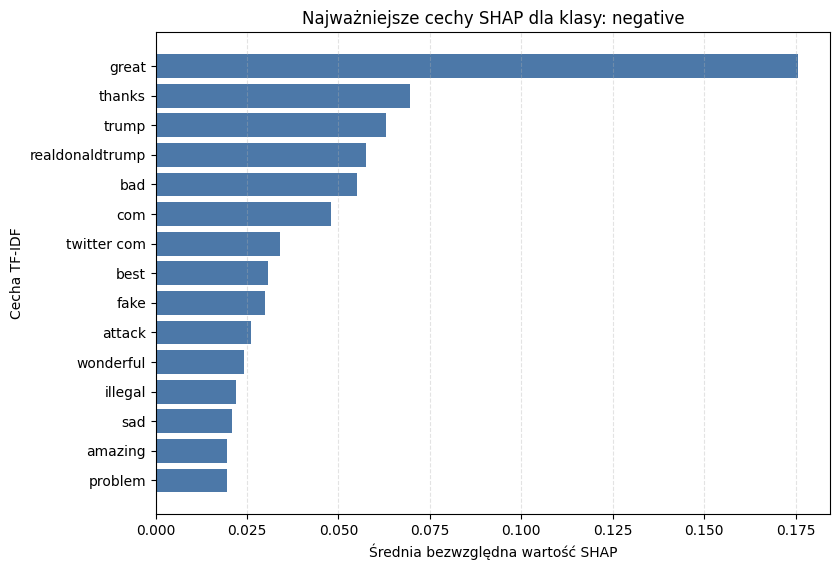

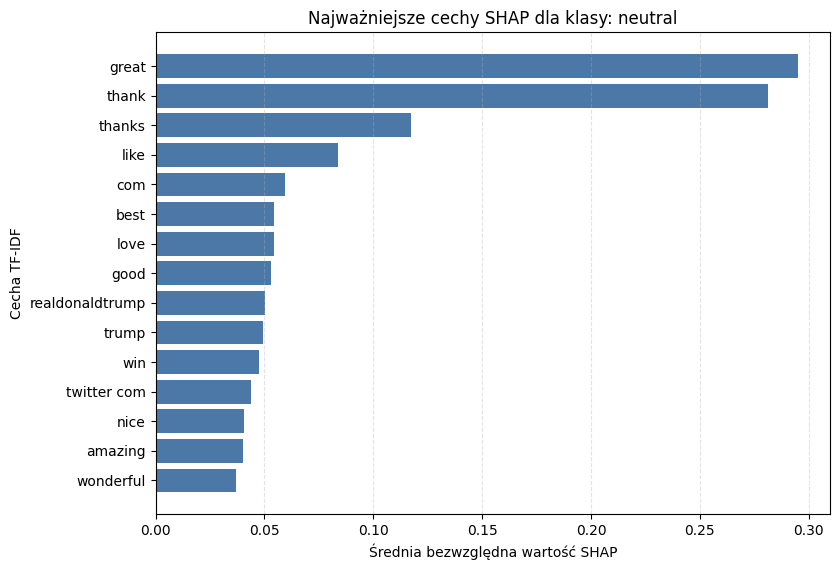

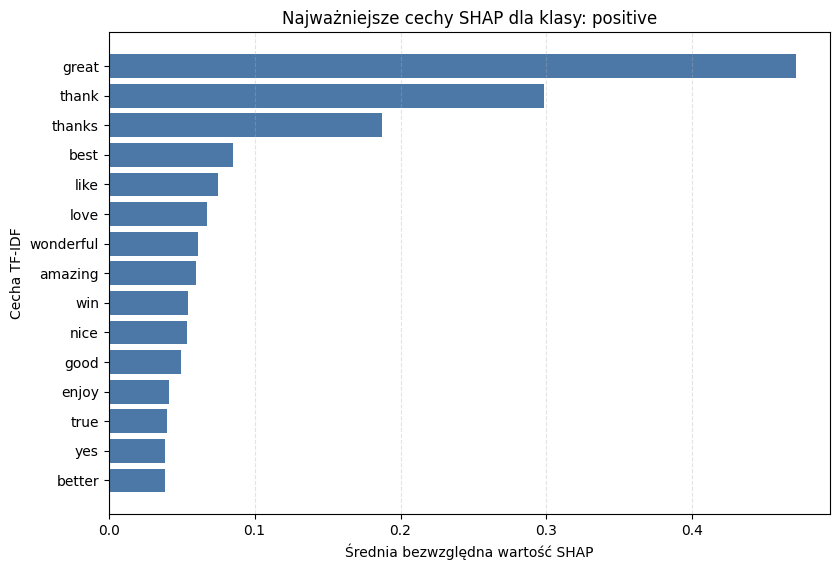

[PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/figures/shap_negative_bar.png'),
 PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/figures/shap_neutral_bar.png'),
 PosixPath('/Users/abalski/Downloads/code-incubator/nprzych-trump-tweets/figures/shap_positive_bar.png')]

In [8]:
def plot_class_shap(class_name: str, output_name: str):
    subset = shap_importance_df[shap_importance_df["class"] == class_name].copy()
    subset = subset.sort_values("mean_abs_shap", ascending=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.8))
    ax.barh(subset["feature"], subset["mean_abs_shap"], color="#4C78A8")
    ax.set_xlabel("Średnia bezwzględna wartość SHAP")
    ax.set_ylabel("Cecha TF-IDF")
    ax.set_title(f"Najważniejsze cechy SHAP dla klasy: {class_name}")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    fig.tight_layout()

    output_path = FIGURES_DIR / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path

saved_paths = []
for class_name in labels:
    saved_paths.append(plot_class_shap(class_name, f"shap_{class_name}_bar.png"))

saved_paths

## Przykładowe lokalne wyjaśnienia

Poniższa tabela pokazuje kilka tweetów ze zbioru testowego, predykcję modelu oraz najsilniejsze cechy SHAP wspierające przewidzianą klasę. Jest to lokalna interpretacja pojedynczych decyzji modelu.

In [9]:
def top_local_features(row_index: int, class_index: int, n: int = 6) -> str:
    values = shap_values[row_index, :, class_index]
    positive_indices = np.argsort(values)[-n:][::-1]
    parts = []
    for feature_index in positive_indices:
        value = values[feature_index]
        if value > 0:
            parts.append(f"{feature_names[feature_index]} ({value:.3f})")
    return ", ".join(parts)

predictions_for_explained = model.predict(X_explain)
example_rows = []

for position in range(min(12, explain_size)):
    predicted_label = predictions_for_explained[position]
    predicted_class_index = labels.index(predicted_label)
    example_rows.append({
        "true_label": explained_labels.iloc[position],
        "predicted_label": predicted_label,
        "top_positive_shap_features": top_local_features(position, predicted_class_index),
        "text": explained_text.iloc[position],
    })

local_examples_df = pd.DataFrame(example_rows)
local_examples_df

,true_label,predicted_label,top_positive_shap_features,text
0,positive,positive,"best (1.842), wins (0.989), entrepreneurs (0.3...",entrepreneurs in the best negotiations everyon...
1,positive,positive,"party (0.457), republican party (0.279), fully...",full attendance in the arena in other words we...
2,positive,positive,"great (1.338), trump (0.042), record (0.039), ...",people are pouring into washington in record n...
3,negative,negative,"unemployment (0.745), low (0.407), cuts (0.361...",economy growing excluding hurricane effects ce...
4,negative,negative,"fight (0.589), forced (0.472), lower (0.402), ...",how could jeff flake who is setting record low...
5,negative,negative,"fight (1.600), fighting (0.914), mr president ...",realdonaldtrump fight the good fight mr presid...
6,positive,positive,"thank (1.290), party (0.711), approval (0.669)...",approval rating in the republican party thank you
7,negative,negative,"bad (0.945), disgrace (0.590), hurt (0.526), h...",major wall street journal opinion piece today ...
8,positive,positive,"join (1.420), center (0.182), pme (0.180), mai...",will be in bangor maine today join me pme at t...
9,positive,positive,"best (1.605), ones (0.209), make (0.173), don ...",sometimes your best investments are the ones y...


## Krótkie podsumowanie

Analiza SHAP wskazuje, że model opiera decyzje głównie na słowach i krótkich frazach jednoznacznie skorelowanych z etykietami VADER. Dla klasy pozytywnej istotne są przede wszystkim słowa pochwalne i grzecznościowe, dla klasy negatywnej słowa silnie krytyczne, a dla klasy neutralnej częściej pojawiają się sygnały techniczne lub schematyczne frazy. Wynik jest spójny z tym, że model uczy się automatycznych etykiet VADER na reprezentacji TF-IDF.